In [1]:
!pip install opencv-python

In [2]:
import cv2, numpy as np
import os
import matplotlib.pyplot as plt

from google.colab import drive
from google.colab.patches import cv2_imshow

In [17]:
def calibrate_target(image):
    """
    Étape 1 : calibration
    Détecte la cible de fléchettes via la transformée de Hough (cercles) et génère un redressement
    de perspective pour obtenir une vue « à plat » (vue du dessus) de la cible.
    """
    output = image.copy()
    # Convertit l'image couleur (BGR) en niveaux de gris.
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Réduit le bruit
    gray = cv2.medianBlur(gray, 5)

    # Détecte les cercles (ajustez param1 et param2 selon l'éclairage)
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, 1, minDist=100,
                               param1=100, param2=40, minRadius=200, maxRadius=500)

    if circles is not None:
        circles = np.uint16(np.around(circles))
        # On suppose que le plus grand cercle correspond à l'anneau externe de la cible
        # Ne dessine que le premier cercle détecté
        x, y, r = circles[0][0]
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Contour du cercle
        cv2_imshow(output)
        return circles[0, 0] # Renvoie (x, y, rayon)

    # N'affiche le résultat que si aucun cercle n'est détecté. Remplace cv2.imshow par cv2_imshow.
    # print("Pas de cercle détecté pour la calibration. Affichage de l'image sans cercle.")
    # cv2_imshow(output)
    return None

In [4]:
def get_dart_impact(ref_gray, current_gray):
    """
    Étapes 2 & 3 : différence et seuillage
    Calcule la différence absolue pour trouver le nouvel objet (la fléchette).
    """
    # 1. Différence absolue
    diff = cv2.absdiff(ref_gray, current_gray)

    # 2. Seuillage (le flou gaussien réduit le bruit avant seuillage)
    blurred = cv2.GaussianBlur(diff, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 25, 255, cv2.THRESH_BINARY)

    # 3. Morphologie : ouverture pour enlever le petit bruit, fermeture pour combler les trous de la fléchette
    kernel = np.ones((3,3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    return thresh

In [5]:
def process_frame(reference_gray, current_frame, board_center, board_radius):
    """
    Pipeline de traitement principal pour une seule caméra.
    Traite une image pour détecter de nouveaux impacts de fléchettes et calculer les scores.
    """
    # 1. Prétraitement : s'assurer que l'image courante est en niveaux de gris et de même taille que la référence
    current_gray = cv2.cvtColor(current_frame, cv2.COLOR_BGR2GRAY)

    if current_gray.shape != reference_gray.shape:
        current_gray = cv2.resize(current_gray, (reference_gray.shape[1], reference_gray.shape[0]))

    # 2. Détection d'impact (différence + seuillage)
    thresh = get_dart_impact(reference_gray, current_gray)

    # 3. Identification de la pointe (contours)
    tips = find_dart_tip(thresh)

    results = []
    for tip in tips:
        # 4. Logique de score
        score = calculate_score(tip, board_center, board_radius)
        results.append({"point": tip, "score": score})

    return results, thresh

In [6]:
def find_dart_tip(thresh_image):
    """
    Étapes 4 & 5 : analyse des contours
    Identifie la pointe de la fléchette comme le point le plus éloigné du centre de la cible
    ou le point le plus « pointu » du contour.
    """
    contours, _ = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    tips = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 100: # Filtre le bruit
            continue

        # Utilise l'enveloppe convexe pour trouver une pointe potentielle
        hull = cv2.convexHull(cnt)

        # La pointe est souvent le point de plus forte courbure
        # ou simplement le point du contour le plus proche du bull (centre)
        # Pour une configuration à 120°, la pointe est souvent le point le plus « bas » ou le plus « haut »
        # selon l'angle de la caméra.
        # On approxime la pointe via le centroïde et une logique de point le plus éloigné
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            tips.append((cx, cy))

    return tips

In [14]:
# Conseils d'optimisation pour Raspberry Pi :
# 1. Redimensionner les images à 640x480 pour accélérer le traitement.
# 2. Utiliser 'cv2.UMat' pour l'accélération matérielle OpenCL si disponible.
# 3. Utiliser une ROI (région d'intérêt) pour rogner l'image autour du cercle de la cible.

def apply_roi(image, center, radius):
    cx, cy = center
    r = int(radius * 1.1)
    y1, y2 = max(0, cy-r), cy+r
    x1, x2 = max(0, cx-r), cx+r
    return image[y1:y2, x1:x2]

In [15]:
def calculate_score(point, center, radius):
    """
    Étape 6 : logique de score
    Associe (x, y) à un score de fléchettes en fonction de la distance et de l'angle.
    """
    x, y = point
    # Convertit en int standard pour éviter les débordements numpy uint16 lors des calculs
    cx, cy = int(center[0]), int(center[1])
    radius = float(radius)

    dx = float(x - cx)
    dy = float(y - cy)

    # Calcule la distance et l'angle
    dist = np.sqrt(dx**2 + dy**2)
    angle = np.degrees(np.arctan2(-dy, dx)) # -dy car l'axe Y est inversé dans les images
    if angle < 0: angle += 360

    # Multiplicateurs standard de la cible (rayons relatifs au rayon de la cible)
    r_ratio = dist / radius

    # Logique des secteurs (1-20)
    sectors = [6, 13, 4, 18, 1, 20, 5, 12, 9, 14, 11, 8, 16, 7, 19, 3, 17, 2, 15, 10]
    idx = int((angle + 9) / 18) % 20
    base_score = sectors[idx]

    if r_ratio < 0.05: return 50 # Bull intérieur (50)
    if r_ratio < 0.12: return 25 # Bull extérieur (25)
    if 0.53 < r_ratio < 0.60: return base_score * 3 # Triple
    if 0.93 < r_ratio < 1.0: return base_score * 2 # Double
    if r_ratio > 1.0: return 0 # Manqué

    return base_score

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


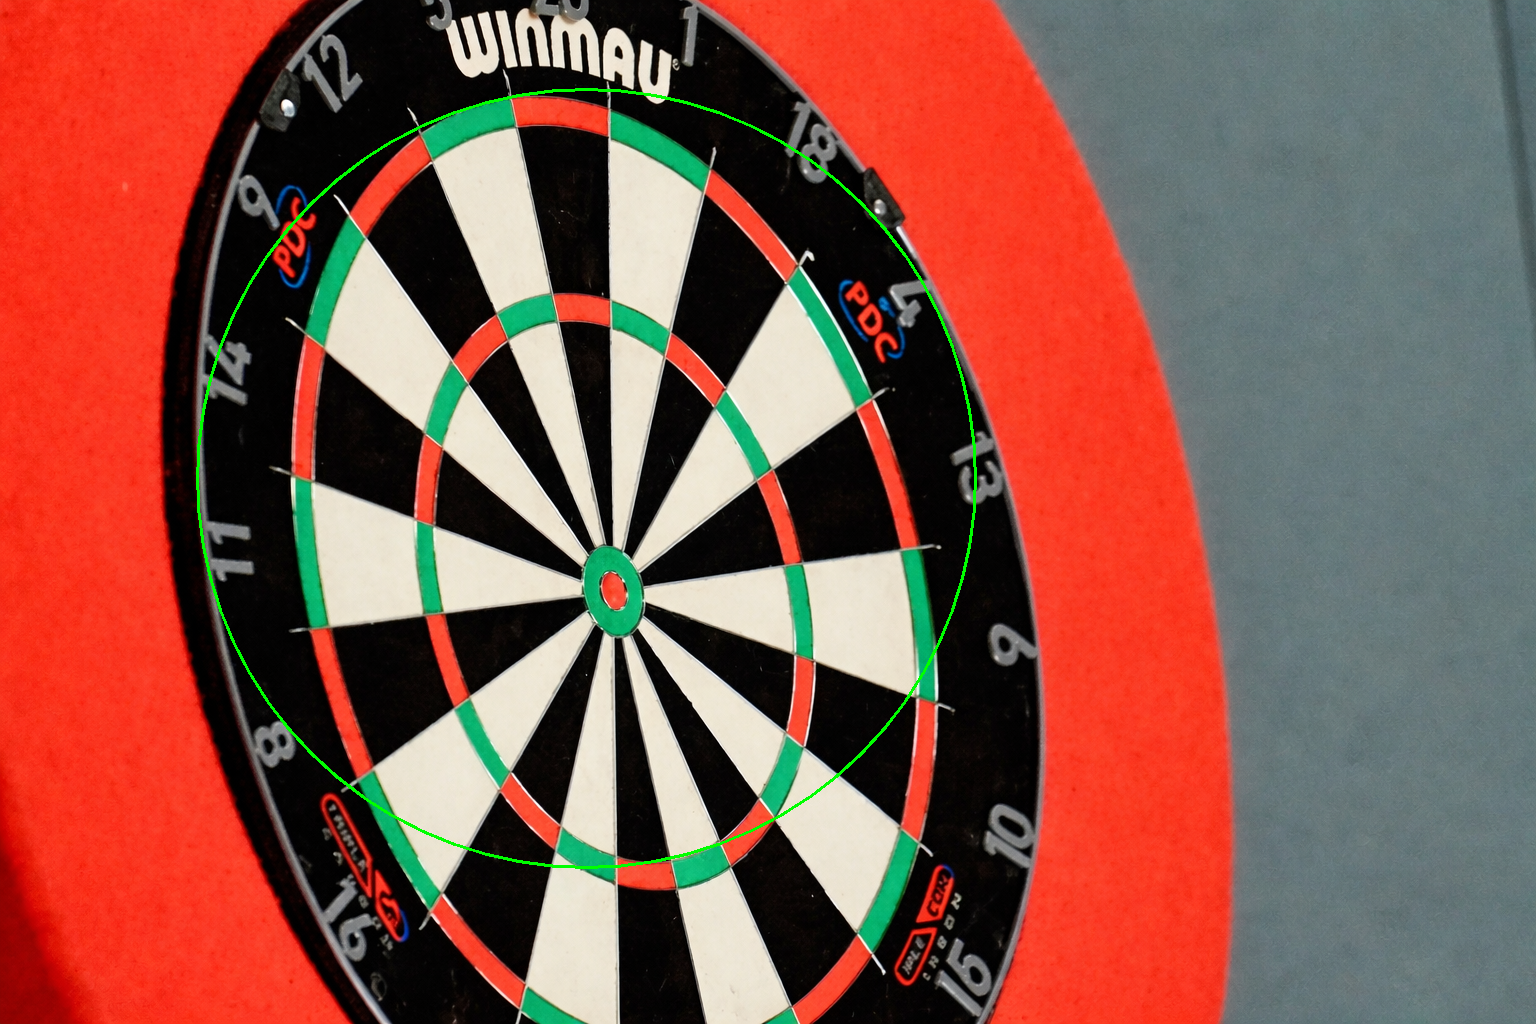

Board Detected! Center: (np.uint16(586), np.uint16(478)), Radius: 389
Detected impact at (1047, 1018) - Calculated Score: 0
Detected impact at (291, 927) - Calculated Score: 0
Detected impact at (1073, 857) - Calculated Score: 0
Detected impact at (2, 787) - Calculated Score: 0
Detected impact at (1492, 53) - Calculated Score: 0
Detected impact at (618, 526) - Calculated Score: 2


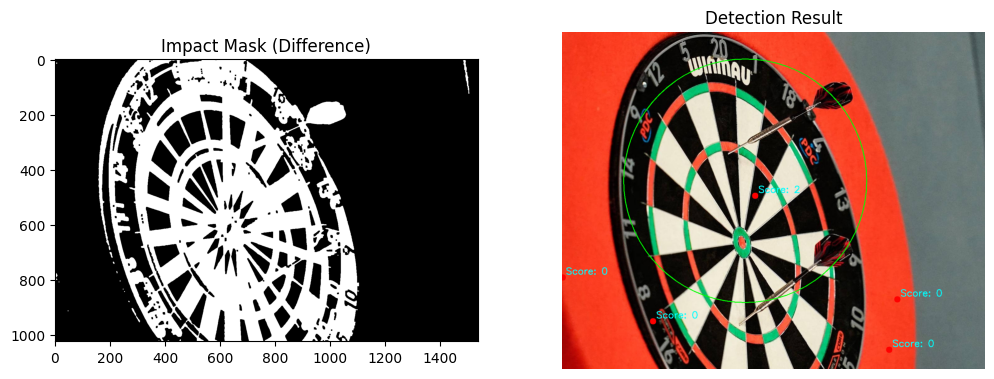

In [18]:
drive.mount('/content/drive')

# Vérification de l'existence des fichiers
file1 = 'drive/MyDrive/board_vide.png'
file2 = 'drive/MyDrive/board_avec_flechette.jpg'

if not os.path.exists(file1) or not os.path.exists(file2):
    print(f"Fichiers non trouvés. Recherche {file1} et {file2}...")
    !ls /content/
else:
    # 1. Charger les images
    img_empty = cv2.imread(file1)
    img_dart = cv2.imread(file2)

    # 2. Calibration sur la cible vide
    board_data = calibrate_target(img_empty)

    if board_data is not None:
        x_c, y_c, radius = board_data
        center = (x_c, y_c)
        print(f"Cible détectée! Centre: {center}, Rayon: {radius}")

        # 3. Traitement de l'image avec la fléchette
        ref_gray = cv2.cvtColor(img_empty, cv2.COLOR_BGR2GRAY)
        results, thresh = process_frame(ref_gray, img_dart, center, radius)

        # 4. Visualisation
        output_img = img_dart.copy()
        cv2.circle(output_img, center, radius, (0, 255, 0), 2)

        if not results:
            print("Pas de fléchettes détectées. Essayez d'ajuster le threshold dans get_dart_impact.")

        for res in results:
            pt = res['point']
            score = res['score']
            cv2.circle(output_img, pt, 10, (0, 0, 255), -1)
            cv2.putText(output_img, f"Score: {score}", (pt[0]+10, pt[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
            print(f"Impact détecté à {pt} - Score calculé : {score}")

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.title("Masque d'impact (Différence)")
        plt.imshow(thresh, cmap='gray')

        plt.subplot(1, 2, 2)
        plt.title("Résultat de détection")
        plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()
    else:
        print("Impossible de détecter la cible. Vérifier les paramètres d'éclairage (lighting) ou les paramètres de la fonction HoughCircles().")